## **Import Data**

In [4]:
import pandas as pd

path = './Fraud.csv'
data = pd.read_csv(path)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
# 결측치 없음!
data.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [ ]:
# 중복값 없음!
data.duplicated().sum()

0

## **Data Overview**

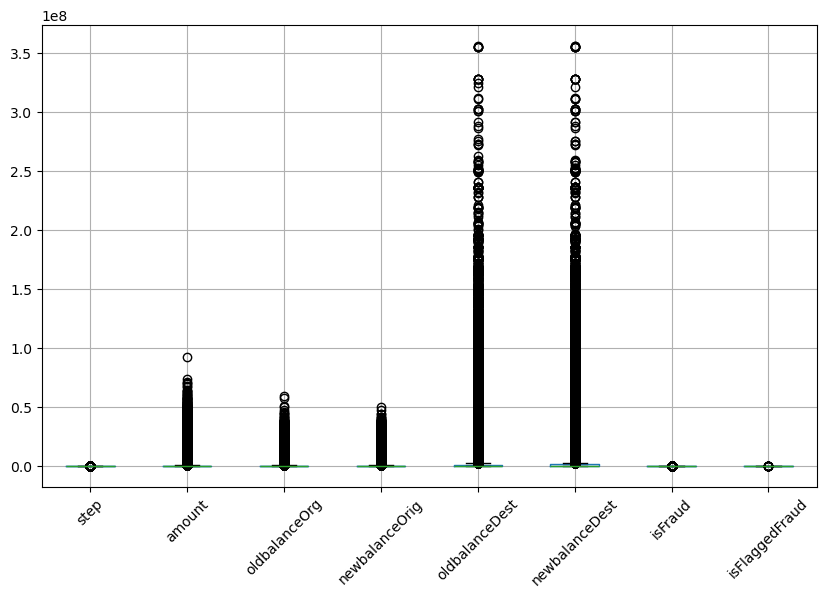

In [10]:
# 이상치 매우 많이 존재
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

data.boxplot()

plt.xticks(rotation=45)

plt.show()

In [14]:
# 각 컬럼별 이상치 비율을 확인하는 함수
def detect_outliers(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    if outliers.empty:
        return column, 0.0
    else:
        percentage = (len(outliers) / len(data)) * 100
        return column, percentage

In [12]:
# 이상치를 제거하는 함수
def remove_outliers(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    result = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

    result.reset_index(drop=True)
    return result

In [15]:
# 5 ~ 17% 까지 이상치 존재
for column in data.select_dtypes(include=['int64', 'float64']):
    column_, percentage = detect_outliers(data, column)
    print(f'Column: {column}\noutliers: {percentage:.2f}%\n')

Column: step
outliers: 1.61%

Column: amount
outliers: 5.31%

Column: oldbalanceOrg
outliers: 17.49%

Column: newbalanceOrig
outliers: 16.56%

Column: oldbalanceDest
outliers: 12.36%

Column: newbalanceDest
outliers: 11.61%

Column: isFraud
outliers: 0.13%

Column: isFlaggedFraud
outliers: 0.00%



In [26]:
data['isFraud'].value_counts() / len(data)

isFraud
0    0.998709
1    0.001291
Name: count, dtype: float64

In [16]:
# isFraud와 isFlaggedFraud의 차이점
# isFlaggedFraud는 금액 규모가 큰 사기 거래
# 모든 isFlaggedFraud는 isFraud지만
# 모든 isFraud는 isFlaggedFraud가 아님
fraud_data = data[data['isFraud'] == 1]

print(fraud_data['isFlaggedFraud'].value_counts(), '\n')
print(round(fraud_data['isFlaggedFraud'].value_counts() / len(fraud_data) * 100, 2))

isFlaggedFraud
0    8197
1      16
Name: count, dtype: int64 

isFlaggedFraud
0    99.81
1     0.19
Name: count, dtype: float64


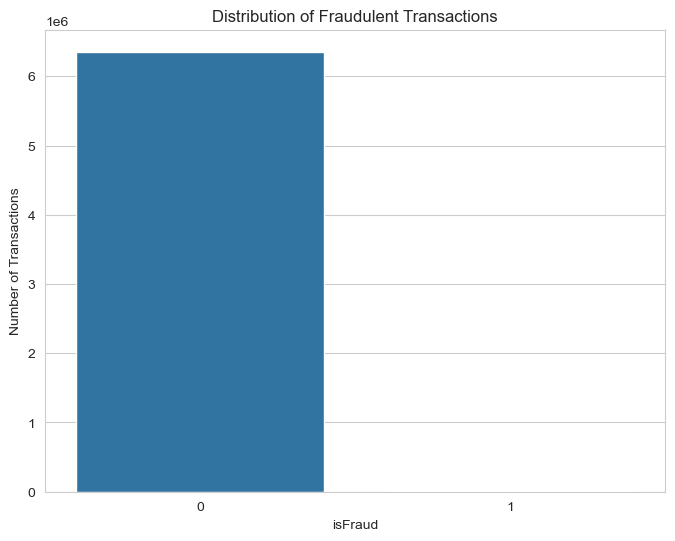

In [17]:
# 전체 거래 내역 중 사기거래 내역 비중 확인
# 데이터의 대부분이 정상거래
import seaborn as sns

sns.set_style('whitegrid')

plt.figure(figsize=(8, 6))

sns.countplot(data=data,
              x='isFraud')

plt.title('Distribution of Fraudulent Transactions')
plt.ylabel('Number of Transactions')

plt.show()

In [27]:
data['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [28]:
data['type'].unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

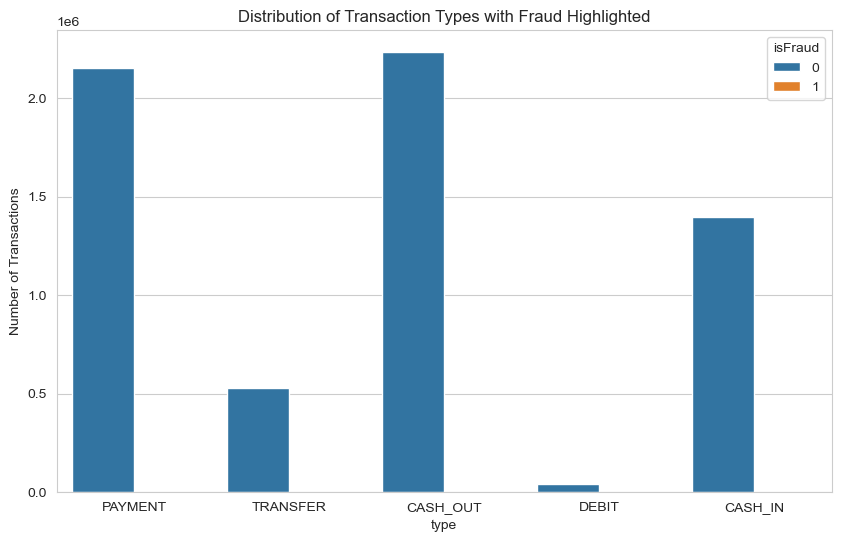

In [19]:
# 정상거래, 사기거래 별 거래 타입의 차이
plt.figure(figsize=(10, 6))

sns.countplot(data=data,
              x='type',
              hue='isFraud')

plt.title('Distribution of Transaction Types with Fraud Highlighted')
plt.ylabel('Number of Transactions')

plt.show()

In [ ]:
# 사기거래는 2가지에서만 발생
data.groupby('isFraud')['type'].value_counts()

isFraud  type    
0        CASH_OUT    2233384
         PAYMENT     2151495
         CASH_IN     1399284
         TRANSFER     528812
         DEBIT         41432
1        CASH_OUT       4116
         TRANSFER       4097
Name: count, dtype: int64

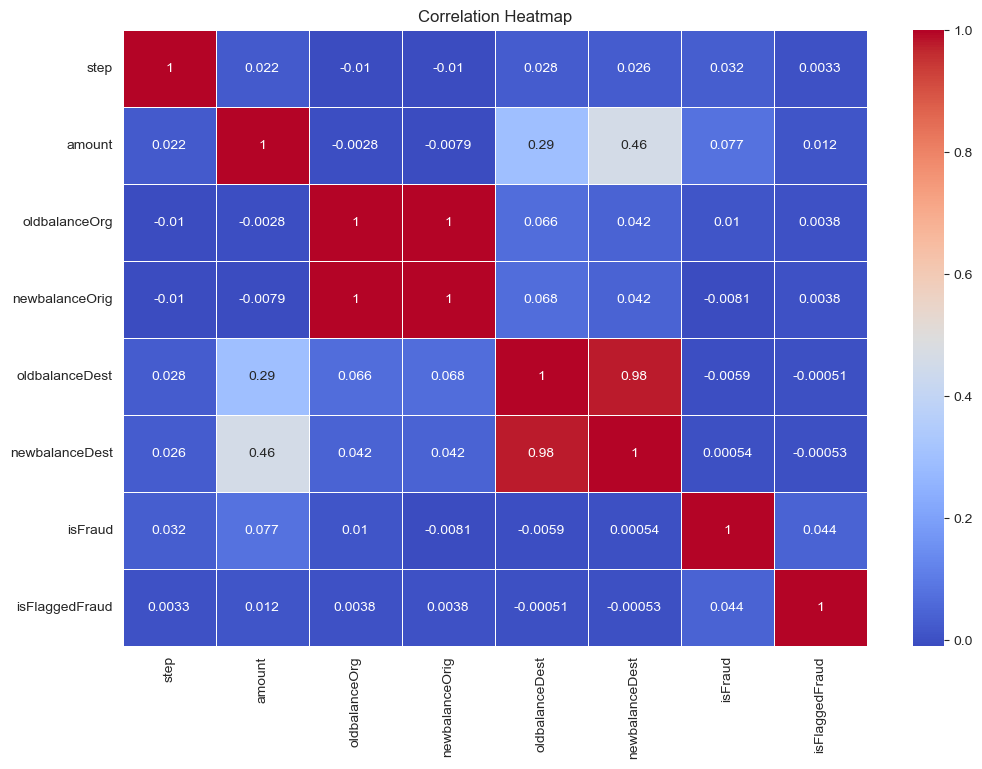

In [22]:
# 컬럼별 상관관계 히트맵 시각화
# 확인 결과 크게 상관성있는 feature은 없어보임
# 직접 확인해 볼 필요가 있음
corr_matrix = data.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title('Correlation Heatmap')

plt.show()

In [23]:
# 거래 전후 금액 차이 추가
data['balanceDiffOrig'] = data['oldbalanceOrg'] - data['newbalanceOrig']
data['balanceDiffDest'] = data['oldbalanceDest'] - data['newbalanceDest']

data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,21182.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [ ]:
# 거래 타입 One-Hot Encoding
data_encoded = pd.get_dummies(data,
                              columns=['type'],
                              drop_first=True) # type 컬럼 삭제
data_encoded.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0,False,False,True,False
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0,False,False,True,False
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0,False,False,False,True
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,21182.0,True,False,False,False
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0,False,False,True,False


## **Multicollinearity (다중공선성)**

In [29]:
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

np.random.seed(10)

x1 = np.random.rand(100)
x2 = x1 + np.random.normal(0, 0.1, 100)

y = 2 * x1 + 3 * x2 + np.random.normal(0, 0.1, 100)

In [30]:
# OLS 회귀모델 생성
x = np.column_stack((x1, x2))
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()

In [ ]:
# VIF (Variance Inflation Factor)를 통해 다중공선성 확인
# 일반적으로 10 이상이면 다중공선성으로 가지고 있다고 해석함
# R-squared는 잘 나왔지만 x1과 x2에서 높은 VIF 값 확인됨
vif = pd.DataFrame()
vif['VIF Factor'] = [variance_inflation_factor(x, i) for i in range(x.shape[1])]

vif['features'] = ['Intercept', 'x1', 'x2']

model.summary(), vif

(<class 'statsmodels.iolib.summary.Summary'>
 """
                             OLS Regression Results                            
 Dep. Variable:                      y   R-squared:                       0.996
 Model:                            OLS   Adj. R-squared:                  0.995
 Method:                 Least Squares   F-statistic:                 1.075e+04
 Date:                Wed, 24 Sep 2025   Prob (F-statistic):          1.36e-114
 Time:                        17:39:04   Log-Likelihood:                 96.574
 No. Observations:                 100   AIC:                            -187.1
 Df Residuals:                      97   BIC:                            -179.3
 Df Model:                           2                                         
 Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
 ---------------------------------------------------------------------

In [ ]:
# x1 변수를 제거하고 다시 계산
# R-squared 값은 조금 떨어졌지만,
# 다중공선성 문제 해결됨
x_reduced = x[:, [0, 2]]
model_reduced = sm.OLS(y, x_reduced).fit()

vif_reduced = pd.DataFrame()
vif_reduced["VIF Factor"] = [variance_inflation_factor(x_reduced, i) for i in range(x_reduced.shape[1])]

vif_reduced['features'] = ["Intercept", 'x2']

model_reduced.summary(), vif_reduced

(<class 'statsmodels.iolib.summary.Summary'>
 """
                             OLS Regression Results                            
 Dep. Variable:                      y   R-squared:                       0.979
 Model:                            OLS   Adj. R-squared:                  0.978
 Method:                 Least Squares   F-statistic:                     4495.
 Date:                Wed, 24 Sep 2025   Prob (F-statistic):           1.09e-83
 Time:                        17:41:37   Log-Likelihood:                 18.642
 No. Observations:                 100   AIC:                            -33.28
 Df Residuals:                      98   BIC:                            -28.07
 Df Model:                           1                                         
 Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
 ---------------------------------------------------------------------

## **EDA**

### **By Transaction Type**

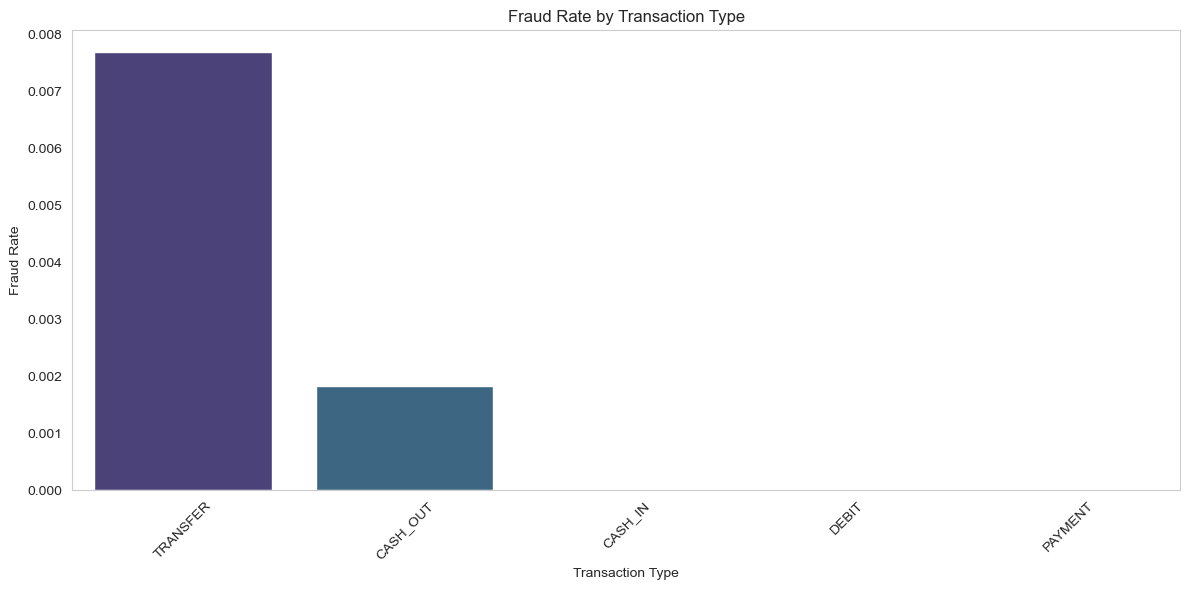

In [37]:
# 거래타입 별 사기여부 비교
# 사기는 두가지 타입에서 발생
fraud_by_type = data.groupby('type').agg({
    'isFraud': 'mean'
}).reset_index().sort_values(by='isFraud', ascending=False)

plt.figure(figsize=(12, 6))

sns.barplot(x='type',
            y='isFraud',
            data=fraud_by_type,
            hue='type',
            palette='viridis')

plt.title('Fraud Rate by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45)

plt.tight_layout()
plt.grid(axis='y')
plt.show()

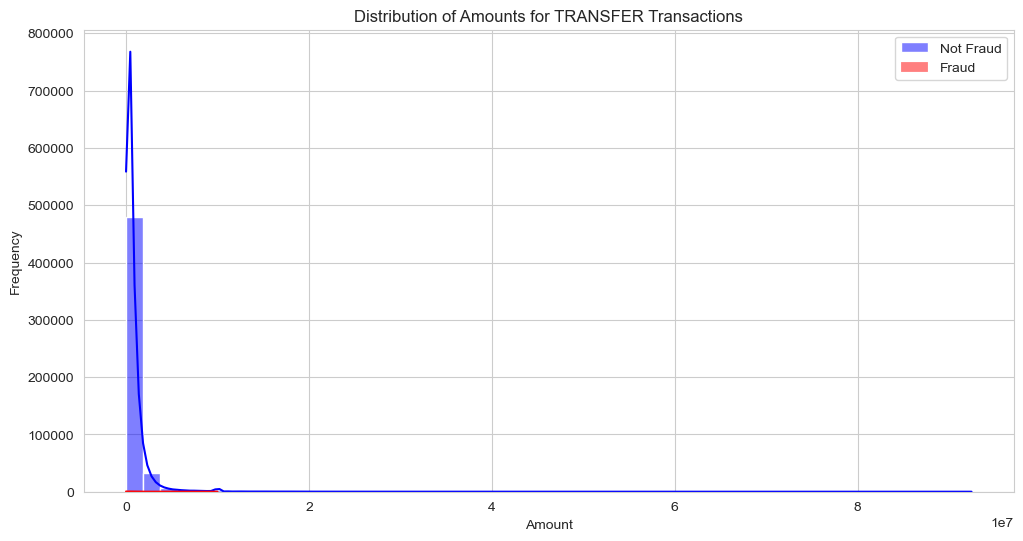

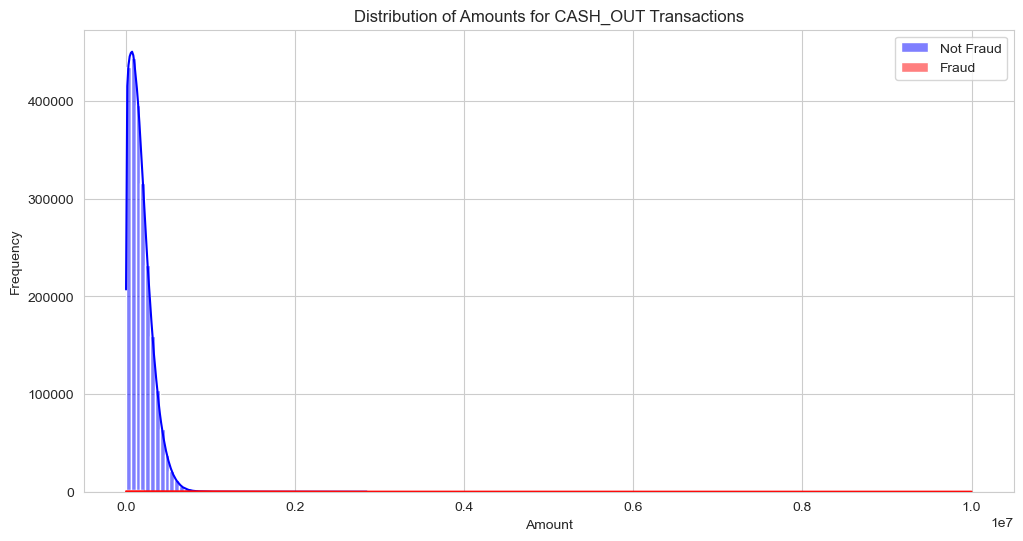

In [38]:
# Tranfer와 Cash_Out 데이터만 비교
# 이상치 존재로 인해서 명확한 분포 확인 어려움
transfer_data = data[data['type'] == 'TRANSFER']
cashout_data = data[data['type'] == 'CASH_OUT']

# TRANSFER
plt.figure(figsize=(12, 6))

sns.histplot(transfer_data[transfer_data['isFraud'] == 0]['amount'],
             bins=50,
             color='blue',
             kde='True',
             label='Not Fraud')
sns.histplot(transfer_data[transfer_data['isFraud'] == 1]['amount'],
             bins=50, 
             color='red',
             kde='True',
             label='Fraud')

plt.title('Distribution of Amounts for TRANSFER Transactions')
plt.xlabel('Amount')
plt.ylabel('Frequency')

plt.legend()
plt.show()

# CASH OUT
plt.figure(figsize=(12, 6))

sns.histplot(cashout_data[cashout_data['isFraud'] == 0]['amount'],
             bins=50,
             color='blue',
             kde='True',
             label='Not Fraud')
sns.histplot(cashout_data[cashout_data['isFraud'] == 1]['amount'],
             bins=50,
             color='red',
             kde='True',
             label='Fraud')

plt.title('Distribution of Amounts for CASH_OUT Transactions')
plt.xlabel('Amount')
plt.ylabel('Frequency')

plt.legend()
plt.show()

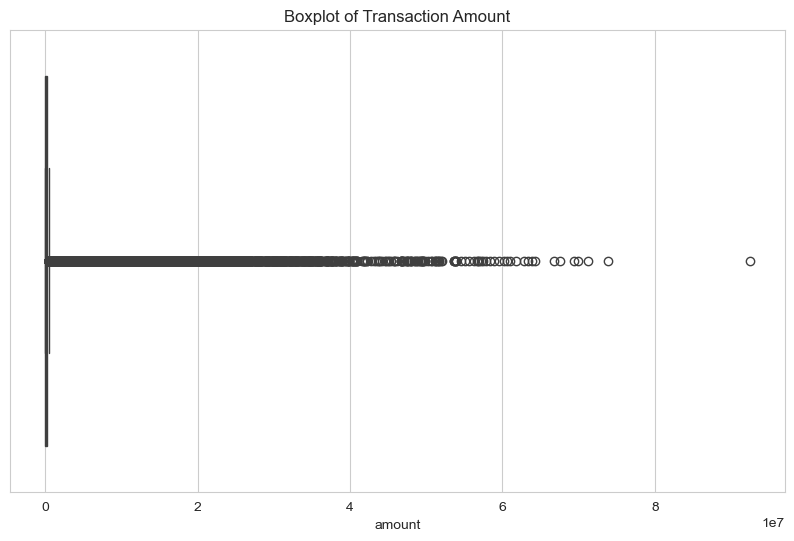

In [39]:
# Boxplot으로 amount의 분포 확인
plt.figure(figsize=(10, 6))

sns.boxplot(data=data_encoded,
            x='amount')

plt.title('Boxplot of Transaction Amount')

plt.show()

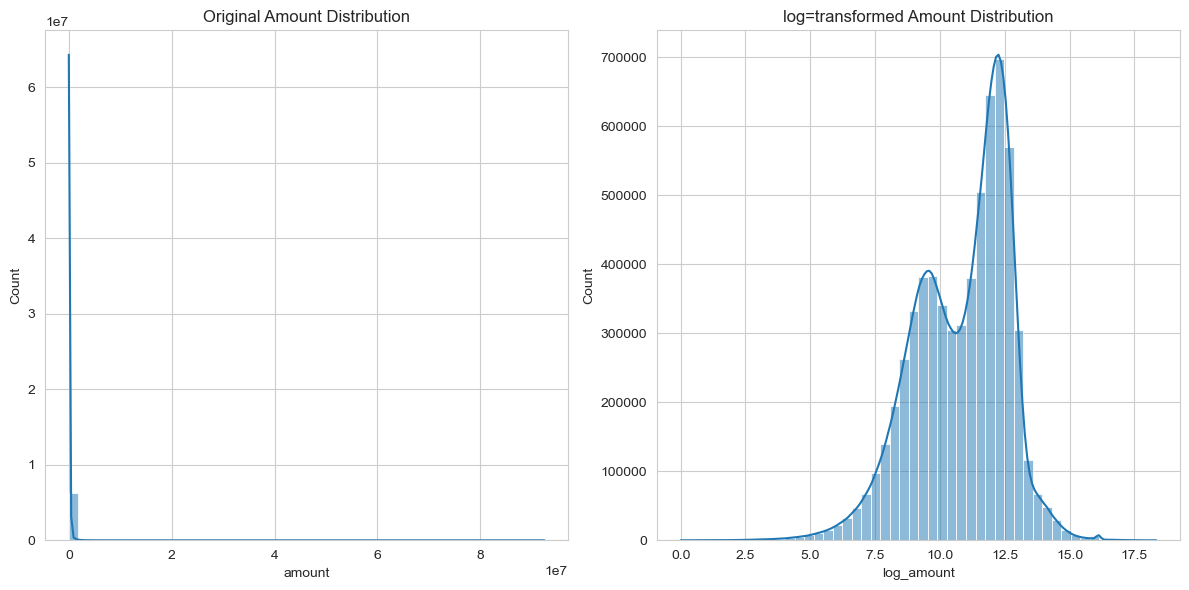

In [ ]:
# 로그 스케일링 후 amount 분포 확인
data_encoded['log_amount'] = np.log1p(data_encoded['amount'])

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(data_encoded['amount'],
             bins=50,
             kde=True)
plt.title('Original Amount Distribution')

plt.subplot(1, 2, 2)
sns.histplot(data_encoded['log_amount'],
             bins=50,
             kde=True)
plt.title('log=transformed Amount Distribution')

plt.tight_layout()
plt.show()

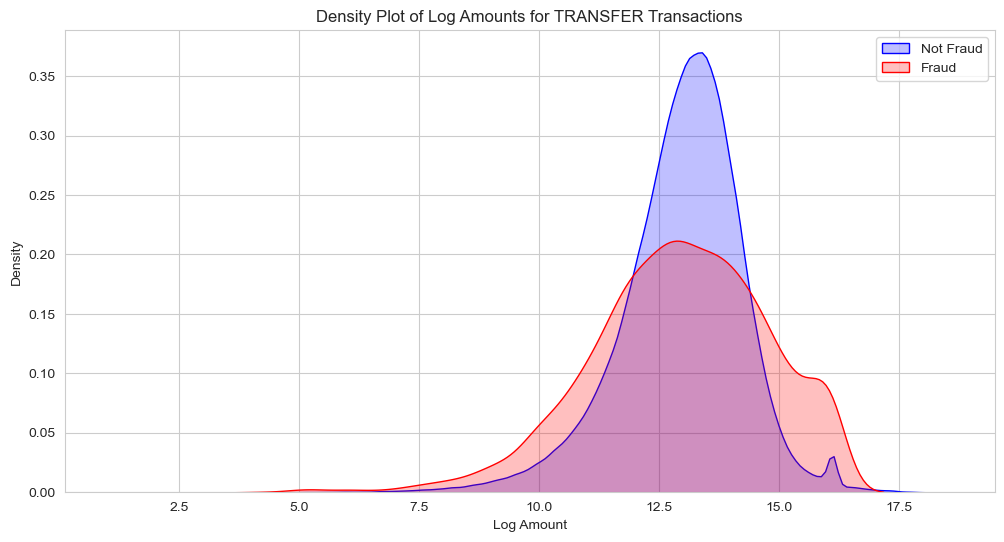

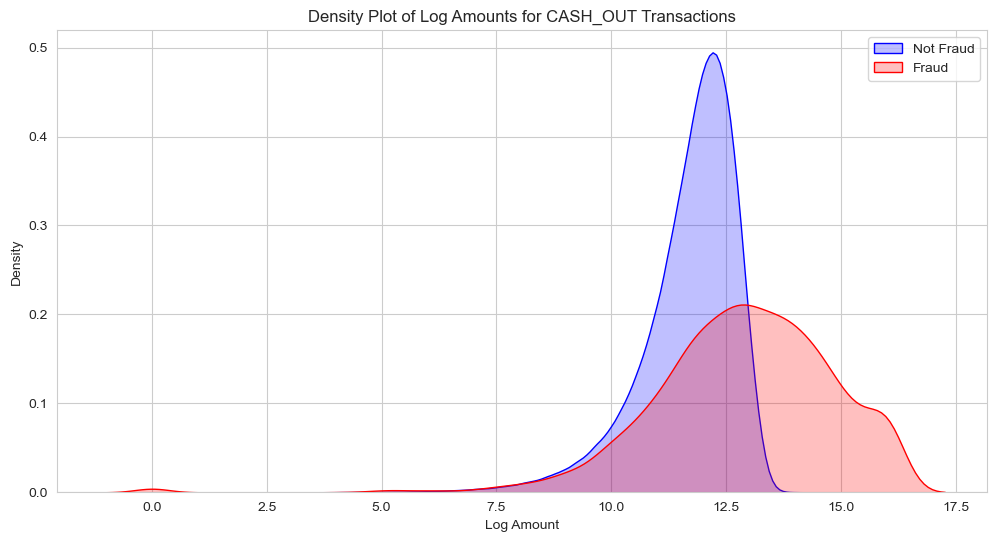

In [42]:
# 로그 스케일링 후 다시 비교
# Cash_Out의 경우 정상거래보다 사기거래에서 더 높은 금액대의 거래가 발생함
# 반면 Transfer에서는 큰 차이를 보이지 않음
# 두 타입 모두 사기거래가 중앙값을 기준으로 편차가 큰 것을 확인할 수 있음.
transfer_data_encoded = data_encoded[data_encoded['type_TRANSFER'] == 1]
cashout_data_encoded = data_encoded[data_encoded['type_CASH_OUT'] == 1]

plt.figure(figsize=(12, 6))

sns.kdeplot(transfer_data_encoded[transfer_data_encoded['isFraud'] == 0]['log_amount'],
            color='blue',
            label='Not Fraud',
            fill=True)
sns.kdeplot(transfer_data_encoded[transfer_data_encoded['isFraud'] == 1]['log_amount'],
            color='red',
            label='Fraud',
            fill=True)

plt.title('Density Plot of Log Amounts for TRANSFER Transactions')
plt.xlabel('Log Amount')
plt.ylabel('Density')

plt.legend()
plt.show()

plt.figure(figsize=(12, 6))

sns.kdeplot(cashout_data_encoded[cashout_data_encoded['isFraud'] == 0]['log_amount'],
            color='blue',
            label='Not Fraud',
            fill=True)
sns.kdeplot(cashout_data_encoded[cashout_data_encoded['isFraud'] == 1]['log_amount'],
            color='red',
            label='Fraud',
            fill=True)

plt.title('Density Plot of Log Amounts for CASH_OUT Transactions')
plt.xlabel('Log Amount')
plt.ylabel('Density')

plt.legend()
plt.show()

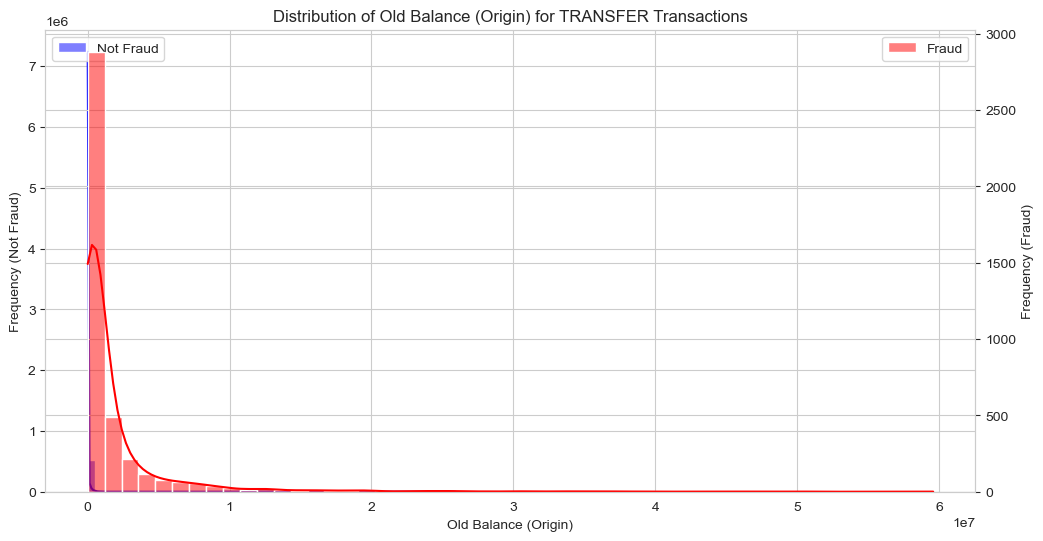

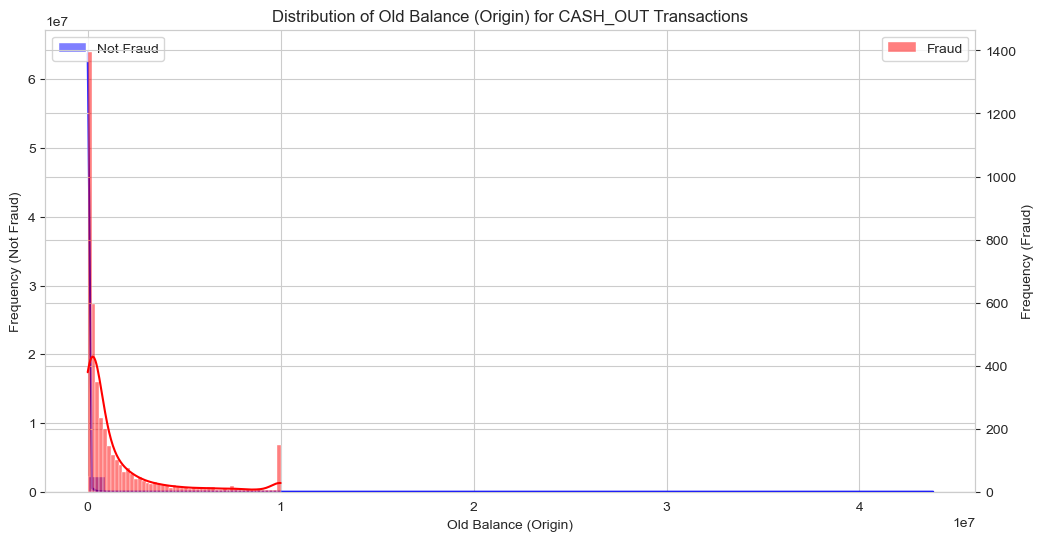

In [ ]:
# oldBalanceOrg (거래 발생 전 발신자의 계좌내역) 비교
# 두 타입 모두 정상거래인 경우 대부분 잔액이 0에 가까운 경우에서 발생
# 사기거래의 경우 두가지 특징을 보이는데,
# 하나는 정상거래와 유사하게 0에 가까운 잔액,
# 다른 하나는 그 다음 구간에서 발생
# 추가로 사기거래는 정상거래에 비해 높은 금액대에서 발생
fig, ax = plt.subplots(figsize=(12, 6))
ax2 = ax.twinx()

sns.histplot(transfer_data_encoded[transfer_data_encoded['isFraud'] == 0]['oldbalanceOrg'],
             bins=50,
             color='blue',
             kde=True,
             label='Not Fraud',
             ax=ax)

ax.set_title('Distribution of Old Balance (Origin) for TRANSFER Transactions')
ax.set_xlabel('Old Balance (Origin)')
ax.set_ylabel('Frequency (Not Fraud)')

ax.legend(loc='upper left')

sns.histplot(transfer_data_encoded[transfer_data_encoded['isFraud'] == 1]['oldbalanceOrg'],
             bins=50,
             color='red',
             kde=True,
             label='Fraud',
             ax=ax2)

ax2.set_ylabel('Frequency (Fraud)')

ax2.legend(loc='upper right')
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
ax2 = ax.twinx()

sns.histplot(cashout_data_encoded[cashout_data_encoded['isFraud'] == 0]['oldbalanceOrg'],
             bins=50,
             color='blue',
             kde=True,
             label='Not Fraud',
             ax=ax)

ax.set_title('Distribution of Old Balance (Origin) for CASH_OUT Transactions')
ax.set_xlabel('Old Balance (Origin)')
ax.set_ylabel('Frequency (Not Fraud)')

ax.legend(loc='upper left')

sns.histplot(cashout_data_encoded[cashout_data_encoded['isFraud'] == 1]['oldbalanceOrg'],
             bins=50,
             color='red',
             kde=True,
             label='Fraud',
             ax=ax2)

ax2.set_ylabel('Frequency (Fraud)')

ax2.legend(loc='upper right')
plt.show()

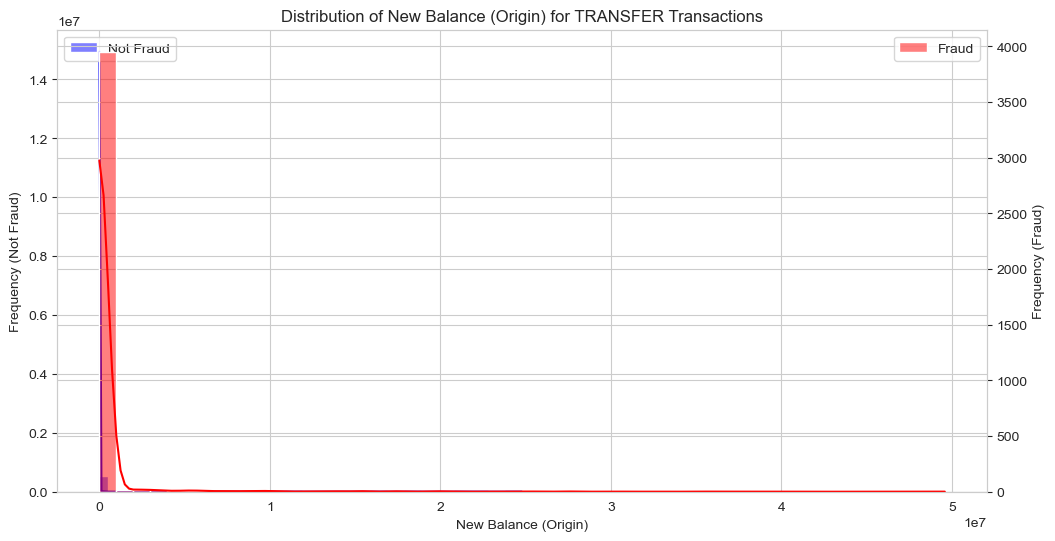

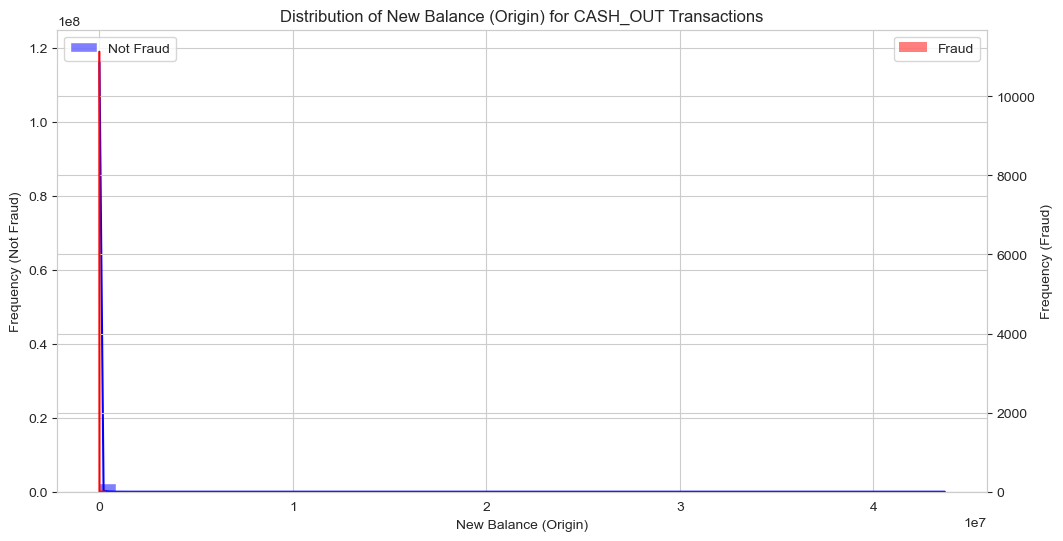

In [ ]:
# newBalanceOrg (거래 발생 후 발신자의 계좌내역) 비교
# 두 타입 모두 사기거래 이후 0에 가깝게 바뀜
fig, ax = plt.subplots(figsize=(12, 6))
ax2 = ax.twinx()

sns.histplot(transfer_data_encoded[transfer_data_encoded['isFraud'] == 0]['newbalanceOrig'],
             bins=50,
             color='blue',
             kde=True,
             label='Not Fraud',
             ax=ax)

ax.set_title('Distribution of New Balance (Origin) for TRANSFER Transactions')
ax.set_xlabel('New Balance (Origin)')
ax.set_ylabel('Frequency (Not Fraud)')

ax.legend(loc='upper left')

sns.histplot(transfer_data_encoded[transfer_data_encoded['isFraud'] == 1]['newbalanceOrig'],
             bins=50,
             color='red',
             kde=True,
             label='Fraud',
             ax=ax2)

ax2.set_ylabel('Frequency (Fraud)')

ax2.legend(loc='upper right')
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
ax2 = ax.twinx()

sns.histplot(cashout_data_encoded[cashout_data_encoded['isFraud'] == 0]['newbalanceOrig'],
             bins=50,
             color='blue',
             kde=True,
             label='Not Fraud',
             ax=ax)

ax.set_title('Distribution of New Balance (Origin) for CASH_OUT Transactions')
ax.set_xlabel('New Balance (Origin)')
ax.set_ylabel('Frequency (Not Fraud)')

ax.legend(loc='upper left')

sns.histplot(cashout_data_encoded[cashout_data_encoded['isFraud'] == 1]['newbalanceOrig'],
             bins=50,
             color='red',
             kde=True,
             label='Fraud',
             ax=ax2)
ax2.set_ylabel('Frequency (Fraud)')

ax2.legend(loc='upper right')
plt.show()

In [47]:
# step을 이용해서 시간 구하기
transfer_data_encoded = transfer_data_encoded.copy()
cashout_data_encoded = cashout_data_encoded.copy()

transfer_data_encoded['hour_of_day'] = transfer_data_encoded['step'] % 24
cashout_data_encoded['hour_of_day'] = cashout_data_encoded['step'] % 24

In [52]:
# 거래 타입별 시간대에 따른 사기 배율
transfer_time_trend = transfer_data_encoded.groupby('hour_of_day').agg({
    'isFraud': ['sum', 'count']
}).reset_index()
transfer_time_trend.columns = ['hour_of_day', 'fraud_count', 'total_count']
transfer_time_trend['fraud_rate'] = transfer_time_trend['fraud_count'] / transfer_time_trend['total_count']

cashout_time_trend = cashout_data_encoded.groupby('hour_of_day').agg({
    'isFraud': ['sum', 'count']
}).reset_index()
cashout_time_trend.columns = ['hour_of_day', 'fraud_count', 'total_count']
cashout_time_trend['fraud_rate'] = cashout_time_trend['fraud_count'] / cashout_time_trend['total_count']

In [53]:
display(transfer_time_trend.head(10))
display(cashout_time_trend.head(10))

,hour_of_day,fraud_count,total_count,fraud_rate
0,0,150,6217,0.024127
1,1,178,2107,0.084480
2,2,186,666,0.279279
3,3,163,348,0.468391
4,4,137,235,0.582979
5,5,183,259,0.706564
6,6,179,387,0.462532
7,7,164,1048,0.156489
8,8,184,2643,0.069618
9,9,171,25203,0.006785


,hour_of_day,fraud_count,total_count,fraud_rate
0,0,150,11997,0.012503
1,1,180,3898,0.046178
2,2,186,1256,0.148089
3,3,163,432,0.377315
4,4,137,277,0.494585
5,5,183,373,0.490617
6,6,179,517,0.346228
7,7,164,1494,0.109772
8,8,184,7659,0.024024
9,9,170,94825,0.001793


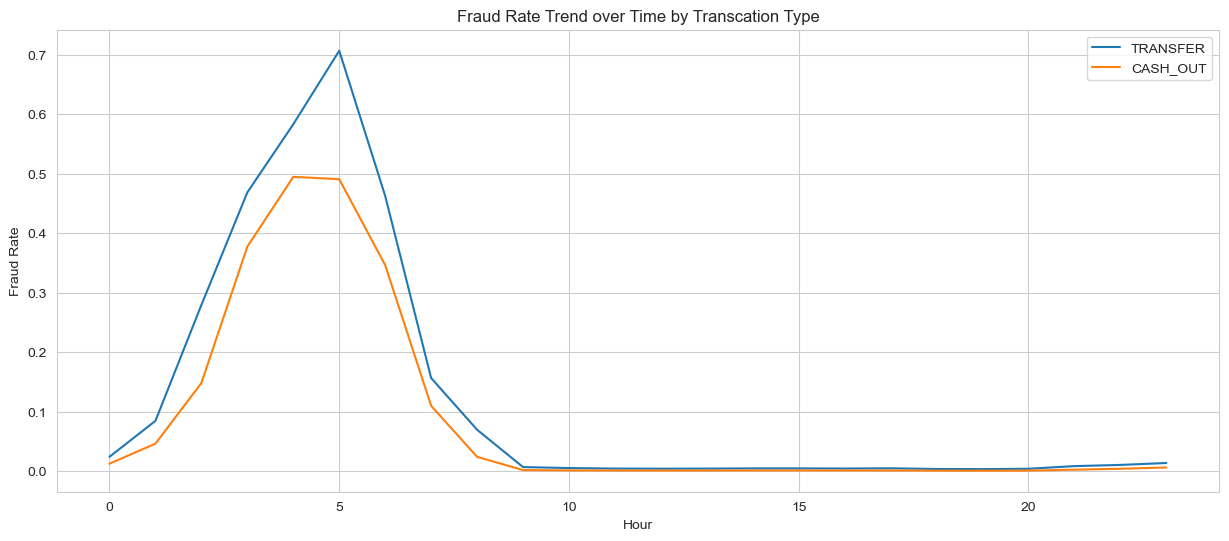

In [54]:
# 거래 타입별 시간대에 따른 사기 비율 시각화
# 새벽 시간대에 거래가 적게 발생하는 점을 감안하더라도
# 거래 타입과 무관하게 새벽 시간대에 많이 발생한 것을 볼 수 있음
plt.figure(figsize=(15, 6))

plt.plot(transfer_time_trend['hour_of_day'],
         transfer_time_trend['fraud_rate'],
         label='TRANSFER')
plt.plot(cashout_time_trend['hour_of_day'],
         cashout_time_trend['fraud_rate'],
         label='CASH_OUT')

plt.title('Fraud Rate Trend over Time by Transcation Type')
plt.xlabel('Hour')
plt.ylabel('Fraud Rate')

plt.legend()
plt.show()

### **By Segmentation (based on amount) of Transaction**

In [55]:
# 상위 10%를 기준으로 거래 데이터를 두개의 segment로 구분
threshold = data_encoded['amount'].quantile(0.9)

typical_transactions = data_encoded[data_encoded['amount'] <= threshold]
high_value_transactions = data_encoded[data_encoded['amount'] > threshold]

print(f'Number of Typical Transactions: {typical_transactions.shape[0]}')
print(f'Number of High-Value Transactions: {high_value_transactions.shape[0]}')

Number of Typical Transactions: 5726358
Number of High-Value Transactions: 636262


In [56]:
# 각 세그먼트 별 사기 비율
# 금액이 높은 거래가 낮은 거래보다 10배 정도 높음
typical_fraud_rate = typical_transactions['isFraud'].mean()
high_value_fraud_rate = high_value_transactions['isFraud'].mean()

print(f'Fraud Rate in Typical Transactions: {typical_fraud_rate:.2%}')
print(f'Fraud Rate in High-Value Transactions: {high_value_fraud_rate:.2%}')

Fraud Rate in Typical Transactions: 0.07%
Fraud Rate in High-Value Transactions: 0.69%


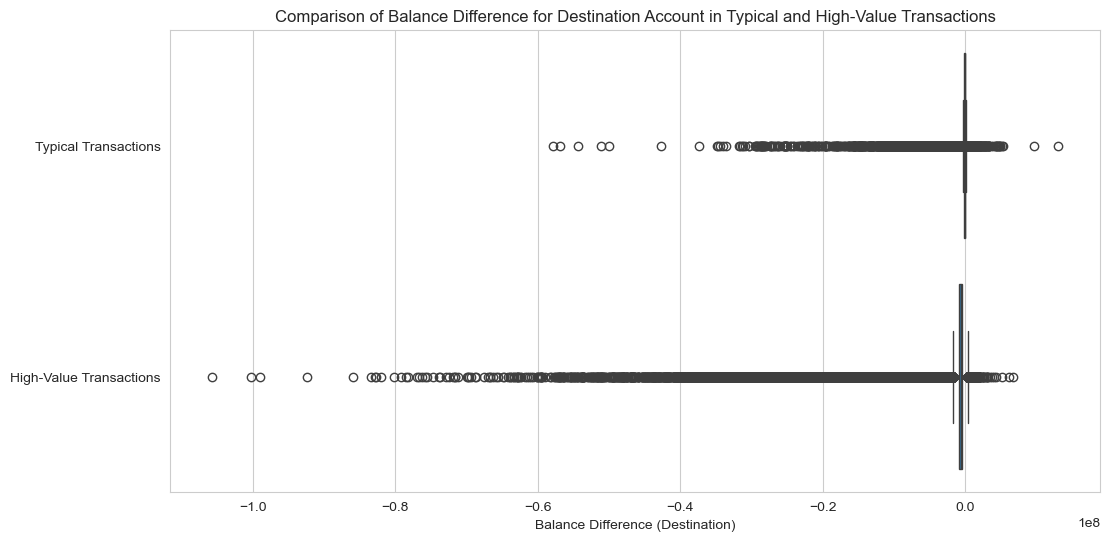

In [60]:
# 세그먼트 별 Destination의 거래 전후 금액 차이
# 이상치때문에 박스안의 데이터의 분포를 확인하기 어렵지만
# 사기거래의 경우 금액적인 측면에서 높고 편차가 큼
plt.figure(figsize=(12, 6))

sns.boxplot(
    x=pd.concat([typical_transactions['balanceDiffDest'], high_value_transactions['balanceDiffDest']]),
    y=['Typical Transactions'] * len(typical_transactions) + 
      ['High-Value Transactions'] * len(high_value_transactions),
    orient='h'
)

plt.title('Comparison of Balance Difference for Destination Account in Typical and High-Value Transactions')
plt.xlabel('Balance Difference (Destination)')

plt.show()


In [61]:
# 이상치 제거
f_typical_transactions = remove_outliers(typical_transactions, 'balanceDiffDest')
f_high_value_transactions = remove_outliers(high_value_transactions, 'balanceDiffDest')

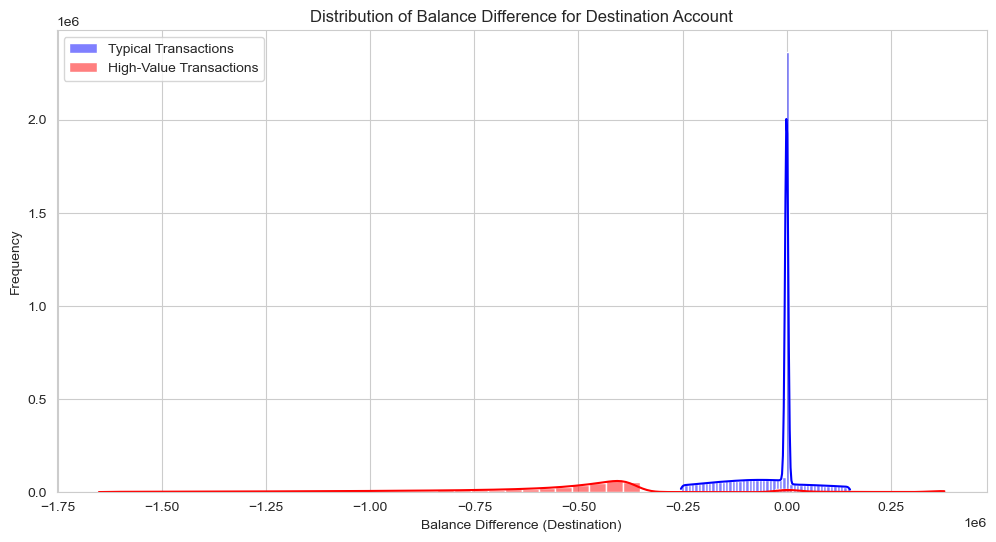

In [62]:
# 이상치 제거 후 세그먼트 별 Destination의 거래 전후 금액 차이 시각화
# 정상거래의 경우 거의 0에 분포하지만
# 사기거래의 경우 금액 분포가 매우 큼
plt.figure(figsize=(12, 6))

sns.histplot(f_typical_transactions['balanceDiffDest'],
             bins=50,
             color='blue',
             kde=True,
             label='Typical Transactions')
sns.histplot(f_high_value_transactions['balanceDiffDest'],
             bins=50,
             color='red',
             kde=True,
             label='High-Value Transactions')

plt.title('Distribution of Balance Difference for Destination Account')
plt.xlabel('Balance Difference (Destination)')
plt.ylabel('Frequency')

plt.legend()
plt.show()

In [63]:
# 세그먼트 별 isFraud와 다른 feature의 상관계수 확인
typical_corr = typical_transactions.corr(numeric_only=True)
high_value_corr = high_value_transactions.corr(numeric_only=True)

typical_isFraud_corr = typical_corr['isFraud']
high_value_isFraud_corr = high_value_corr['isFraud']

typical_isFraud_corr = typical_isFraud_corr.drop('isFraud')
high_value_isFraud_corr = high_value_isFraud_corr.drop('isFraud')

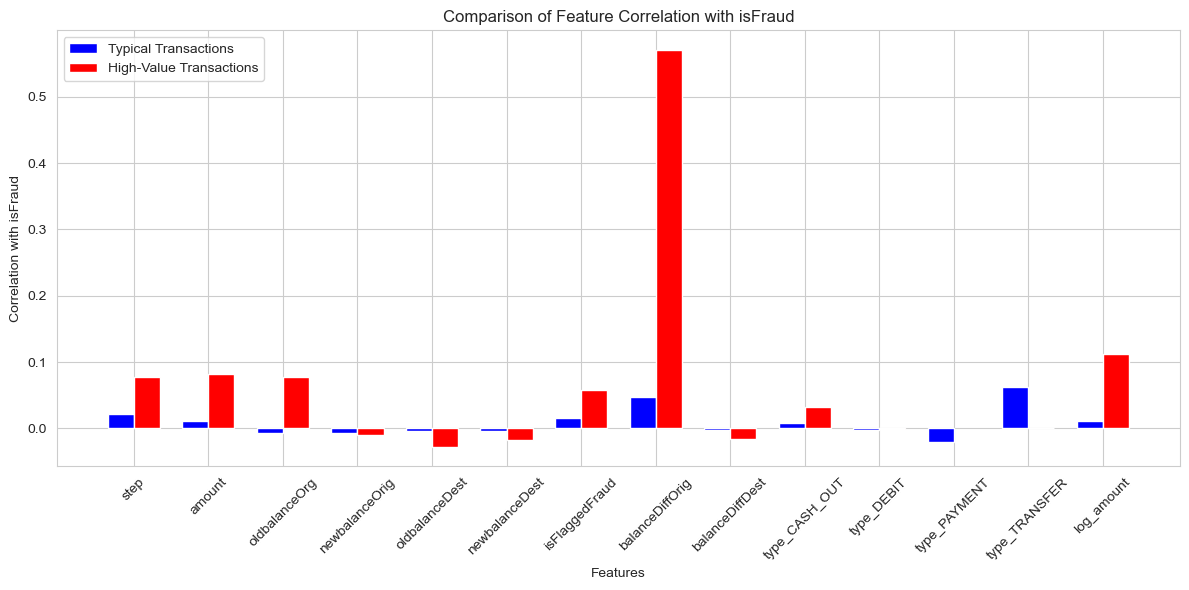

In [64]:
# 상관계수 차이 시각화
plt.figure(figsize=(12, 6))
bar_width = 0.35
indicies = np.arange(len(typical_isFraud_corr))

plt.bar(indicies,
        typical_isFraud_corr,
        bar_width,
        color='blue',
        label='Typical Transactions')
plt.bar(indicies + bar_width,
        high_value_isFraud_corr,
        bar_width,
        color='red',
        label='High-Value Transactions')

plt.title('Comparison of Feature Correlation with isFraud')
plt.xlabel('Features')
plt.ylabel('Correlation with isFraud')
plt.xticks(indicies + bar_width / 2, typical_isFraud_corr.index, rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

### **By Time Trend**

In [72]:
# step으로 groupby 후에 사기 비율 확인
time_analysis = data_encoded.groupby('step').agg({'isFraud': ['count', 'sum']}).reset_index()
time_analysis.columns = ['step', 'total_transactions', 'fraudelent_transactions']
time_analysis.head()

,step,total_transactions,fraudelent_transactions
0,1,2708,16
1,2,1014,8
2,3,552,4
3,4,565,10
4,5,665,6


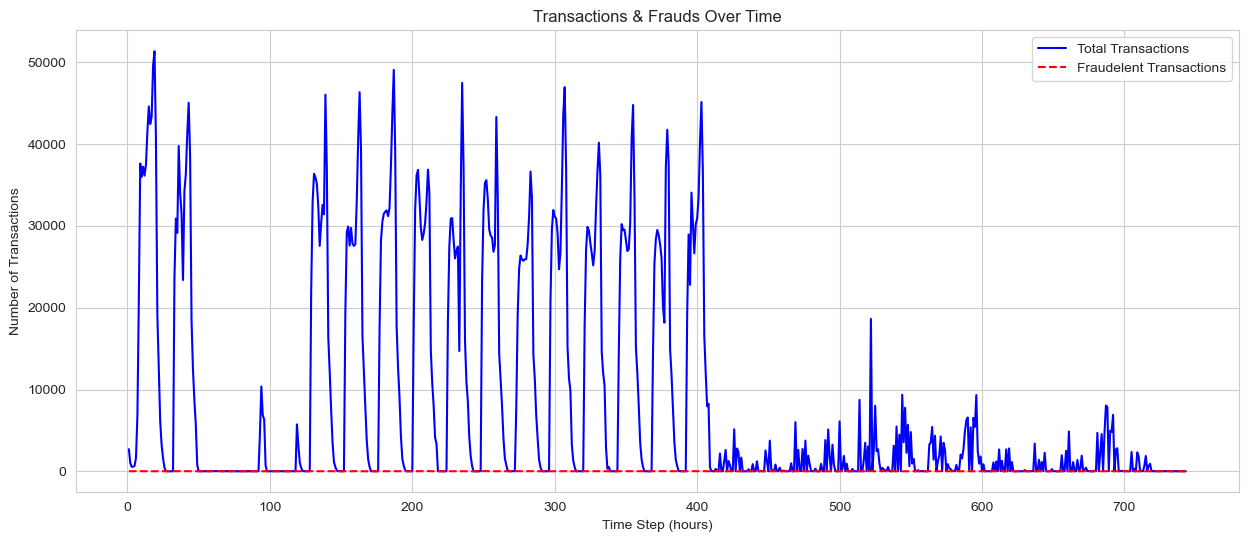

In [80]:
# 시간대 별 전체 거래 내역과 그 중 사기 거래 비율 시각화
# 스케일 차이가 심해서 패턴 확인 어려움
plt.figure(figsize=(15, 6))

plt.plot(time_analysis['step'],
         time_analysis['total_transactions'],
         label='Total Transactions',
         color='blue')
plt.plot(time_analysis['step'],
         time_analysis['fraudelent_transactions'],
         label='Fraudelent Transactions',
         color='red',
         linestyle='dashed')

plt.title('Transactions & Frauds Over Time')
plt.xlabel('Time Step (hours)')
plt.ylabel('Number of Transactions')

plt.legend()
plt.grid(True)
plt.show()

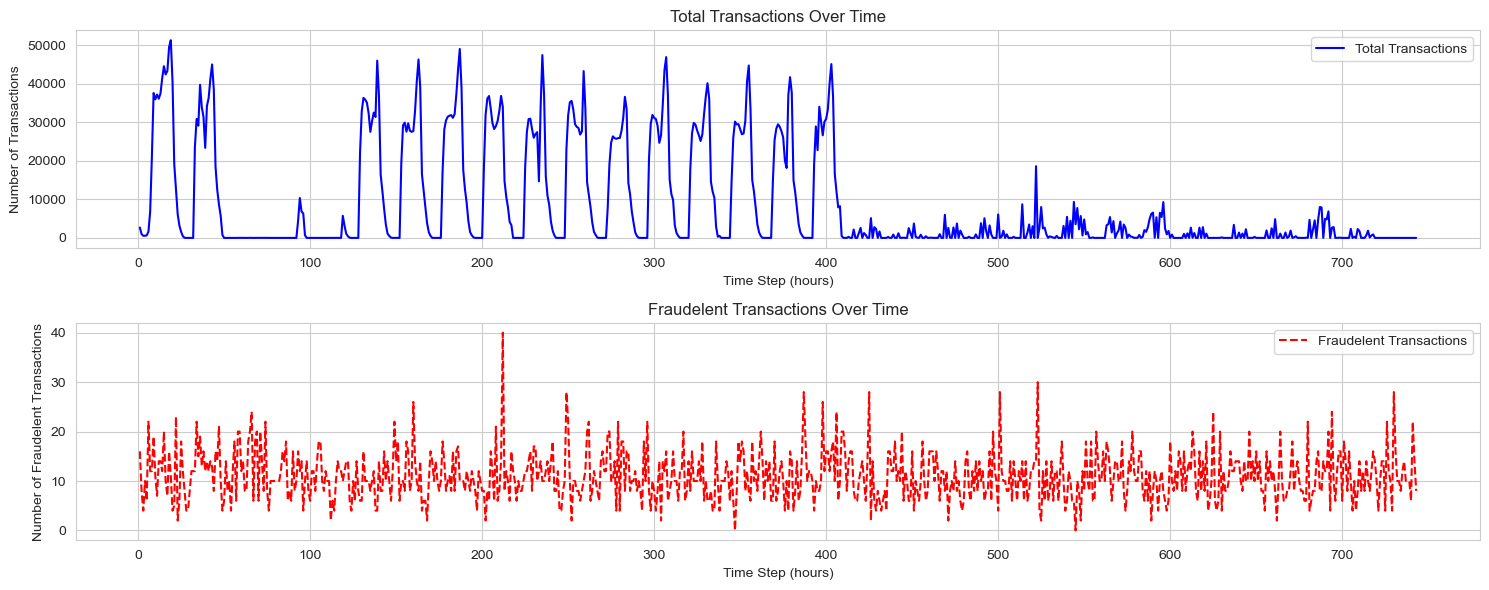

In [81]:
# subplot으로 나눠 보기
# 총 거래 내역 수가 증가해도 사기거래 수는 같이 증가하지 않음
plt.figure(figsize=(15, 6))

plt.subplot(2, 1, 1)
plt.plot(time_analysis['step'],
         time_analysis['total_transactions'],
         label='Total Transactions',
         color='blue')

plt.title('Total Transactions Over Time')
plt.xlabel('Time Step (hours)')
plt.ylabel('Number of Transactions')

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.subplot(2, 1, 2)
plt.plot(time_analysis['step'],
         time_analysis['fraudelent_transactions'],
         label='Fraudelent Transactions',
         color='red',
         linestyle='dashed')

plt.title('Fraudelent Transactions Over Time')
plt.xlabel('Time Step (hours)')
plt.ylabel('Number of Fraudelent Transactions')

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [71]:
# 거래 전후 발신, 수신 계좌 내역 차이
balance_diff_analysis = data_encoded.groupby('step').agg({
    'balanceDiffOrig': 'mean',
    'balanceDiffDest': 'mean'
}).reset_index()
balance_diff_analysis.head()

,step,balanceDiffOrig,balanceDiffDest
0,1,-21091.359158,-240294.921773
1,2,-21942.318570,-34637.678777
2,3,-31121.330743,-11012.750870
3,4,9027.185327,-122853.725434
4,5,-32474.433278,910.379489


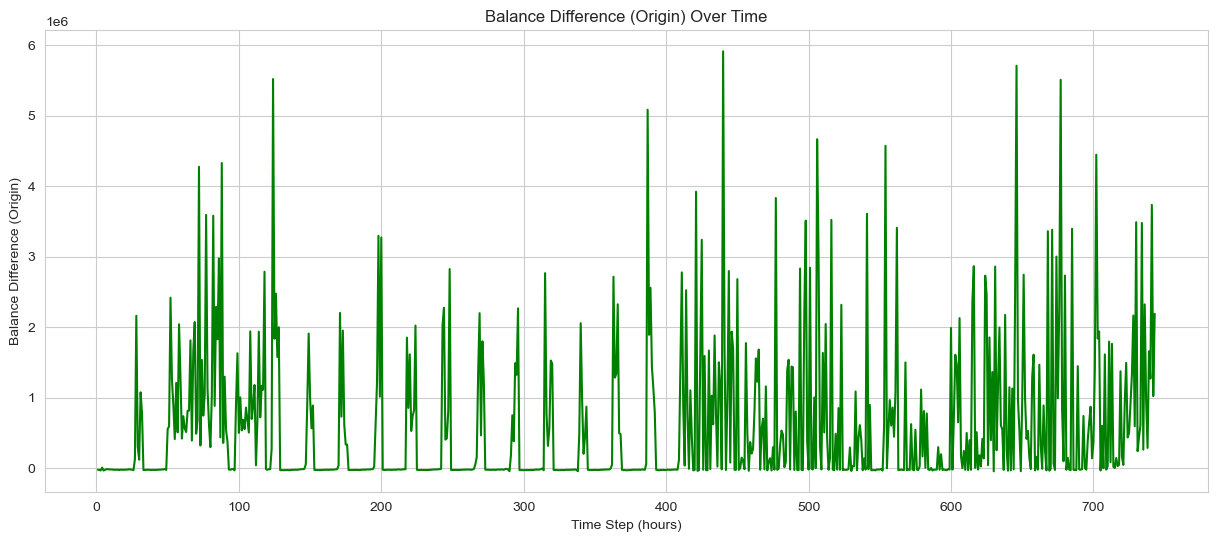

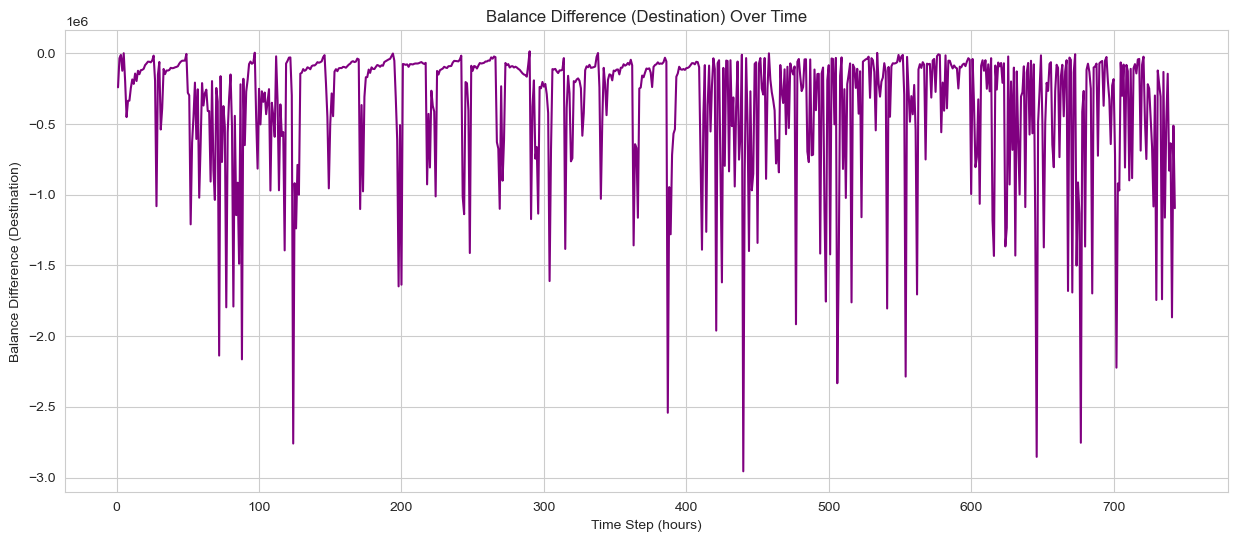

In [73]:
# 발신에서 차이가 크다면 수신에서도 차이가 큰 비슷한 패턴을 보임
plt.figure(figsize=(15, 6))

plt.plot(balance_diff_analysis['step'],
         balance_diff_analysis['balanceDiffOrig'],
         label='Balance Difference (Origin)',
         color='green')

plt.title('Balance Difference (Origin) Over Time')
plt.xlabel('Time Step (hours)')
plt.ylabel('Balance Difference (Origin)')

plt.grid(True)
plt.show()

plt.figure(figsize=(15, 6))

plt.plot(balance_diff_analysis['step'],
         balance_diff_analysis['balanceDiffDest'],
         label='Balance Difference (Destination)',
         color='purple')

plt.title('Balance Difference (Destination) Over Time')
plt.xlabel('Time Step (hours)')
plt.ylabel('Balance Difference (Destination)')

plt.grid(True)
plt.show()

In [74]:
# 이동평균(Moving Average, MA): 시계열 데이터의 잡음을 줄이고 추세를 강조하기 위한 통계기법
# 주어진 시점에서 과거의 특정 기간에 대한 평균값을 계산하고 그 시점의 값을 대체
rolling_mean = time_analysis['fraudelent_transactions'].rolling(window=10).mean()
rolling_std = time_analysis['fraudelent_transactions'].rolling(window=10).std()

# 사기 거래가 기대치보다 큰 시점
spikes = time_analysis[time_analysis['fraudelent_transactions'] > (rolling_mean + 2 * rolling_std)]

print("Steps with significant spikes in fraudelent transactions:\n", spikes['step'].values)

Steps with significant spikes in fraudelent transactions:
 [ 47  84  86 149 160 208 212 241 249 261 296 317 387 398 425 436 501 523
 600 646 680 741]


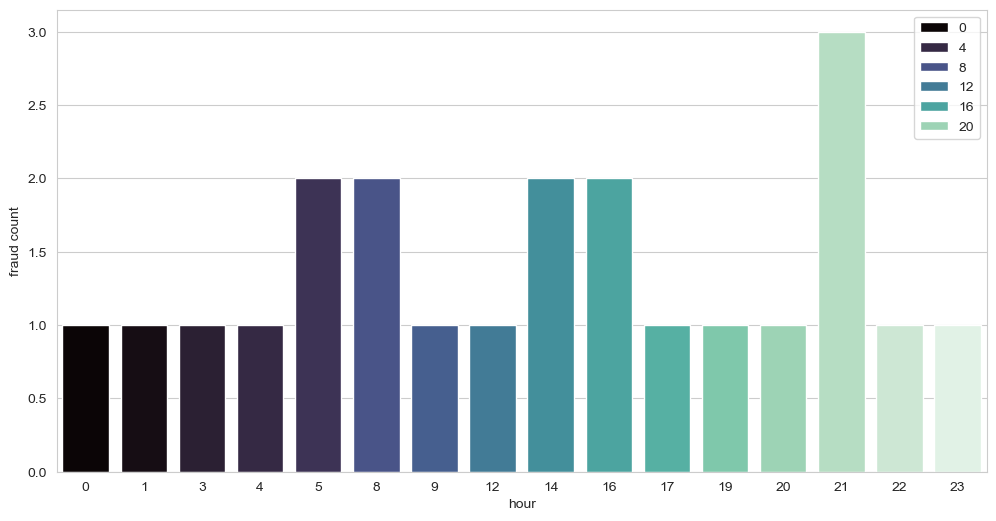

In [82]:
# 시간대 별 spike count
from collections import Counter

spikes_lst = sorted(list(Counter(spikes['step'] % 24).items()))
x = [x for x,_ in spikes_lst]
y = [y for _,y in spikes_lst]

plt.figure(figsize=(12, 6))

sns.barplot(x=x, y=y, hue=x, palette='mako')

plt.xlabel('hour')
plt.ylabel('fraud count')

plt.show()

In [78]:
# step을 이용해 시간 계산
data_encoded['hour_of_day'] = data_encoded['step'] % 24

hourly_analysis = data_encoded.groupby('hour_of_day').agg({
    'isFraud': ['count', 'sum']
}).reset_index()

hourly_analysis.columns = ['hour_of_day', 'total_transactions', 'fraudelent_transactions']
hourly_analysis.head(10)

,hour_of_day,total_transactions,fraudelent_transactions
0,0,71587,300
1,1,27111,358
2,2,9018,372
3,3,2007,326
4,4,1241,274
5,5,1641,366
6,6,3420,358
7,7,8988,328
8,8,26915,368
9,9,283518,341


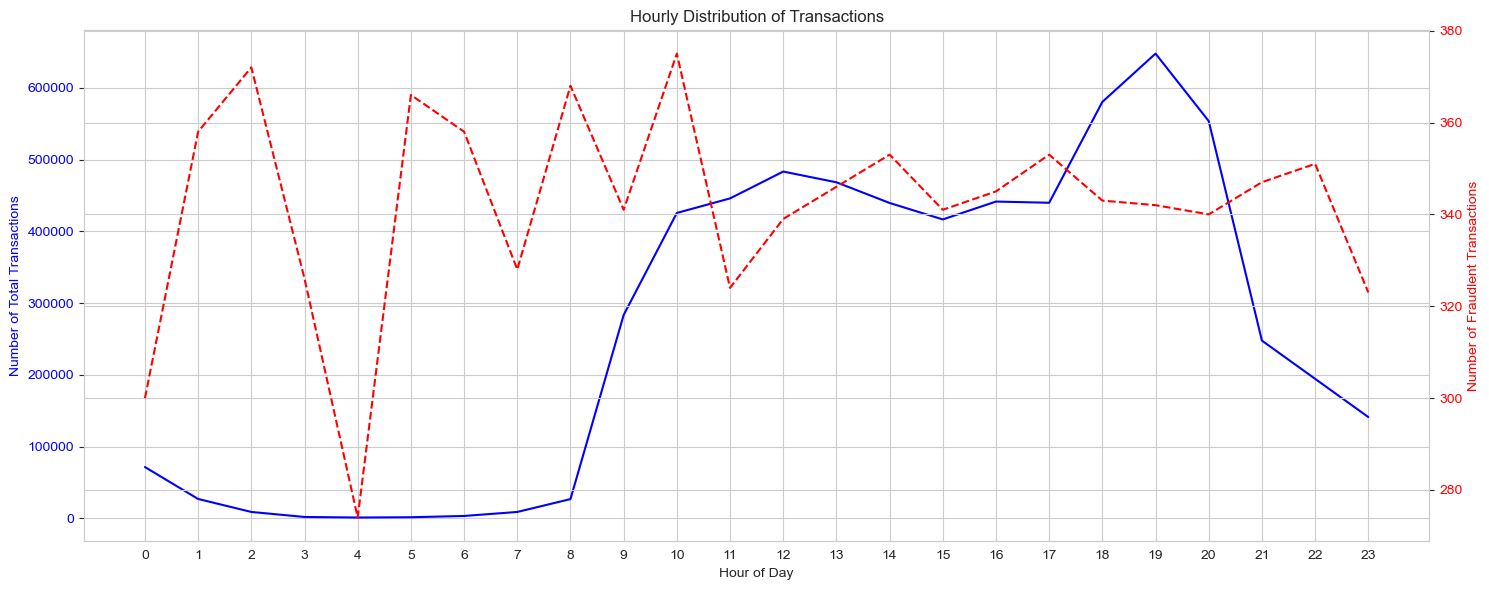

In [79]:
# 시간별 전체 발생 거래 내역과 사기 거래 내역 시각화
# 전체 거래는 새벽 시간대에 다른 시간대보다 거래가 적게 발생한 반면
# 사기 거래는 다른 시간대보다 새벽 시간대에 많이 발생한 것으로 보임
plt.figure(figsize=(15, 6))

ax1 = plt.gca()
ax1.plot(hourly_analysis['hour_of_day'],
         hourly_analysis['total_transactions'],
         label='Total Transactions',
         color='blue')

ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Number of Total Transactions', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(hourly_analysis['hour_of_day'],
         hourly_analysis['fraudelent_transactions'],
         label='Fraudlent Transactions',
         color='red', 
         linestyle='dashed')

ax2.set_ylabel('Number of Fraudlent Transactions', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Hourly Distribution of Transactions')
plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

## **Feature Importance**

### **Statistical Tests**

In [83]:
from scipy.stats import ttest_ind, chi2_contingency

In [84]:
# 독립표본 T-test (두 그룹에서 유의한 차이가 있는지)
# 현재는 p-value가 0.05보다 작으므로 귀무가설을 기각하고 대립가설을 채택한다.
# (두 그룹간에 유의한 차이가 있다.)
np.random.seed(0)

group_x = np.random.normal(50, 10, 100)
group_y = np.random.normal(55, 10, 100)

t_stat_, p_value = ttest_ind(group_x, group_y)

p_value

0.00040627960203623494

In [86]:
# 카이제곱검정 (두 변수가 유의한 관계가 있는지)
# 현재는 p-value가 0.05보다 크므로 귀무가설을 기각하지 못한다.
# 성별 차이와 선호하는 색깔 차이는 통계적으로 유의한 관계가 없다.
data_chi2 = {
    'Preference': np.random.choice(['Red', 'Blue', 'Green'], 300, p=[0.5, 0.3, 0.2]),
    'Gender': np.random.choice(['Male', 'Female'], 300, p=[0.6, 0.4])
}

chi2_df = pd.DataFrame(data_chi2)
chi2_df.head()

,Preference,Gender
0,Green,Female
1,Red,Female
2,Red,Female
3,Red,Male
4,Red,Female


In [87]:
contingency_table_chi2 = pd.crosstab(chi2_df['Preference'], chi2_df['Gender'])
contingency_table_chi2

Gender,Female,Male
Preference,,
Blue,32,49
Green,26,34
Red,59,100


In [88]:
chi2_stat_, chi2_p_value_sample, dof_, expected_ = chi2_contingency(contingency_table_chi2)
chi2_p_value_sample

0.6970376885104776

In [89]:
def ttest(data, feature):
    group1 = data[data['isFraud'] == 0][feature]
    group2 = data[data['isFraud'] == 1][feature]

    t_stat_, p_value = ttest_ind(group1, group2)
    return p_value

def chi2_test(data, feature):
    contingency_table = pd.crosstab(data[feature], data['isFraud'])

    chi2_stat_, chi2_p_value_sample, dof_, expected_ = chi2_contingency(contingency_table)
    return chi2_p_value_sample

In [90]:
# 연속형, 범주형에 따라 feature 분리
continuous_features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balanceDiffOrig', 'balanceDiffDest', 'log_amount']
categorical_features = ['type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']

In [91]:
# 각 feature 타입에 맞게 t-검정과 카이제곱검정 시행
ttest_results = {feature: ttest(data_encoded, feature) for feature in continuous_features}
chi2_results = {feature: chi2_test(data_encoded, feature) for feature in categorical_features}

In [92]:
ttest_results

{'amount': 0.0,
 'oldbalanceOrg': 1.0542893553023227e-144,
 'newbalanceOrig': 7.168312431103147e-94,
 'oldbalanceDest': 7.463206943535623e-50,
 'newbalanceDest': 0.17689674407002928,
 'balanceDiffOrig': 0.0,
 'balanceDiffDest': 0.0,
 'log_amount': 0.0}

In [93]:
chi2_results

{'type_CASH_OUT': 3.568458816669272e-177,
 'type_DEBIT': 3.512829753658977e-13,
 'type_PAYMENT': 0.0,
 'type_TRANSFER': 0.0}

In [97]:
# p_value 기준으로 feature sorting
all_p_values = {**ttest_results, **chi2_results}
all_p_values

{'amount': 0.0,
 'oldbalanceOrg': 1.0542893553023227e-144,
 'newbalanceOrig': 7.168312431103147e-94,
 'oldbalanceDest': 7.463206943535623e-50,
 'newbalanceDest': 0.17689674407002928,
 'balanceDiffOrig': 0.0,
 'balanceDiffDest': 0.0,
 'log_amount': 0.0,
 'type_CASH_OUT': 3.568458816669272e-177,
 'type_DEBIT': 3.512829753658977e-13,
 'type_PAYMENT': 0.0,
 'type_TRANSFER': 0.0}

In [98]:
adjusted_p_values = {}
for key, value in all_p_values.items():
    epsilon = 1e-300
    if value < epsilon:
        adjusted_p_values[key] = epsilon
    else:
        adjusted_p_values[key] = value

# 시각화를 용이하게 하기 위해 -log 변환
negative_log_p_values = {key: -np.log10(value) for key, value in adjusted_p_values.items()}

sorted_p_values = dict(sorted(negative_log_p_values.items(), key=lambda item: item[1], reverse=True))

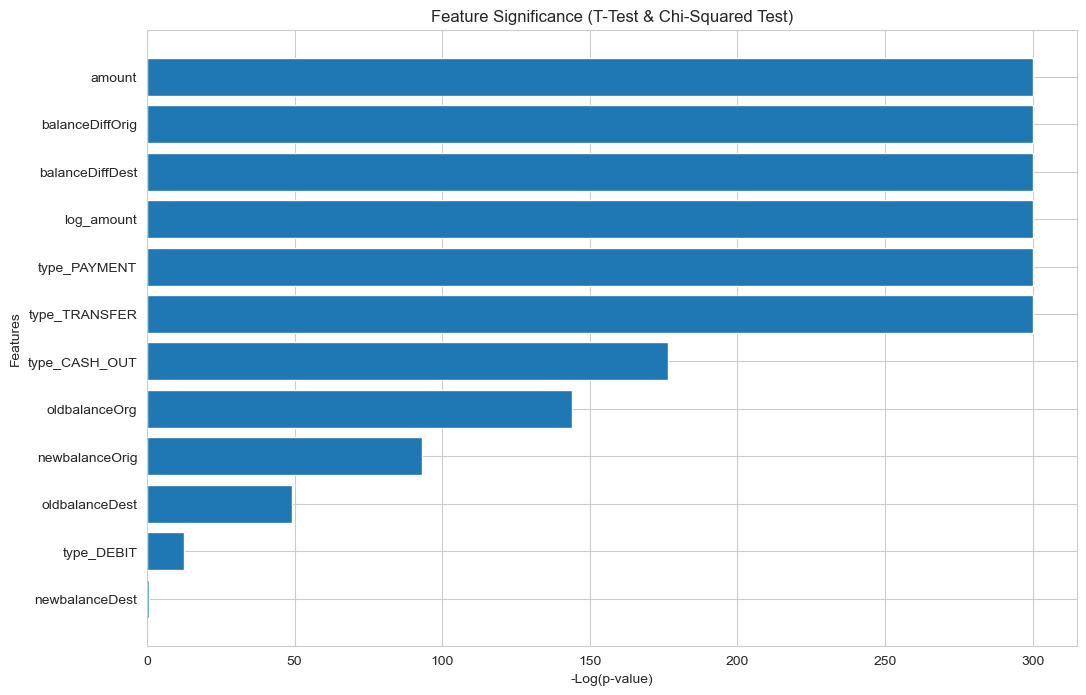

In [99]:
# feature별 p-value 시각화
plt.figure(figsize=(12, 8))

plt.barh(list(sorted_p_values.keys()), list(sorted_p_values.values()))

plt.title('Feature Significance (T-Test & Chi-Squared Test)')
plt.xlabel('-Log(p-value)')
plt.ylabel('Features')

plt.gca().invert_yaxis()
plt.show()

### **Permutation Importance**

- Permutation Importance: 각 feature가 머신러닝 모델에 얼마나 중요한지를 판단하는 방법
- 모델의 성능을 측정하고, 특정 feature의 값을 무작위로 섞어서 성능이 얼마나 변하는지 관찰한다.
- 만약 feature를 섞었을 때 머신러닝 모델의 성능이 크게 떨어진다면 해당 feature는 중요하다고 볼 수 있다.

In [100]:
# Permutation Importance 방법을 사용하기 위해 먼저 머신러닝 모델을 학습시켜야한다.
# RandomForest 모델 학습
# 정확도가 99% -> 현재 데이터 불균형 매우 심함
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 데이터 샘플링 (10%)
data_sample = data_encoded.sample(frac=0.1, random_state=42)

# 불필요한 feature 제거
x = data_sample.drop(['isFraud', 'nameOrig', 'nameDest'], axis=1)
y = data_sample['isFraud']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# 학습
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(x_train, y_train)

print(f'Model Accuracy on Test Set: {clf.score(x_test, y_test)}')

Model Accuracy on Test Set: 0.9997223371874329


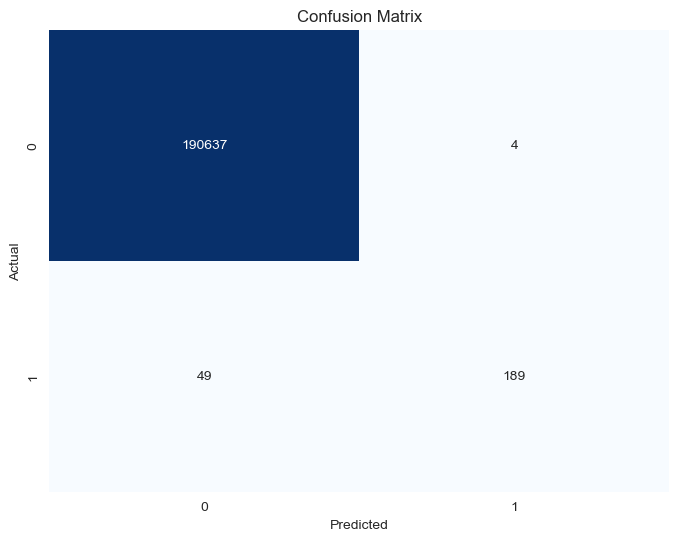

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    190641
           1       0.98      0.79      0.88       238

    accuracy                           1.00    190879
   macro avg       0.99      0.90      0.94    190879
weighted avg       1.00      1.00      1.00    190879



In [102]:
# Precesion: 모델이 참이라고 예측한 것 중 실제로 참인 비율
# Recall: 실제 참인것 중 모델이 참이라고 예측한 비율
from sklearn.metrics import confusion_matrix, classification_report

y_pred = clf.predict(x_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(cm, 
            annot=True, 
            fmt='g', 
            cmap='Blues', 
            cbar=False)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

report = classification_report(y_test, y_pred)
print(report)

In [ ]:
# 주요 feature 탐색
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(clf,
                                         x_test,
                                         y_test,
                                         n_repeats=30,
                                         random_state=42,
                                         n_jobs=-1)
perm_importance

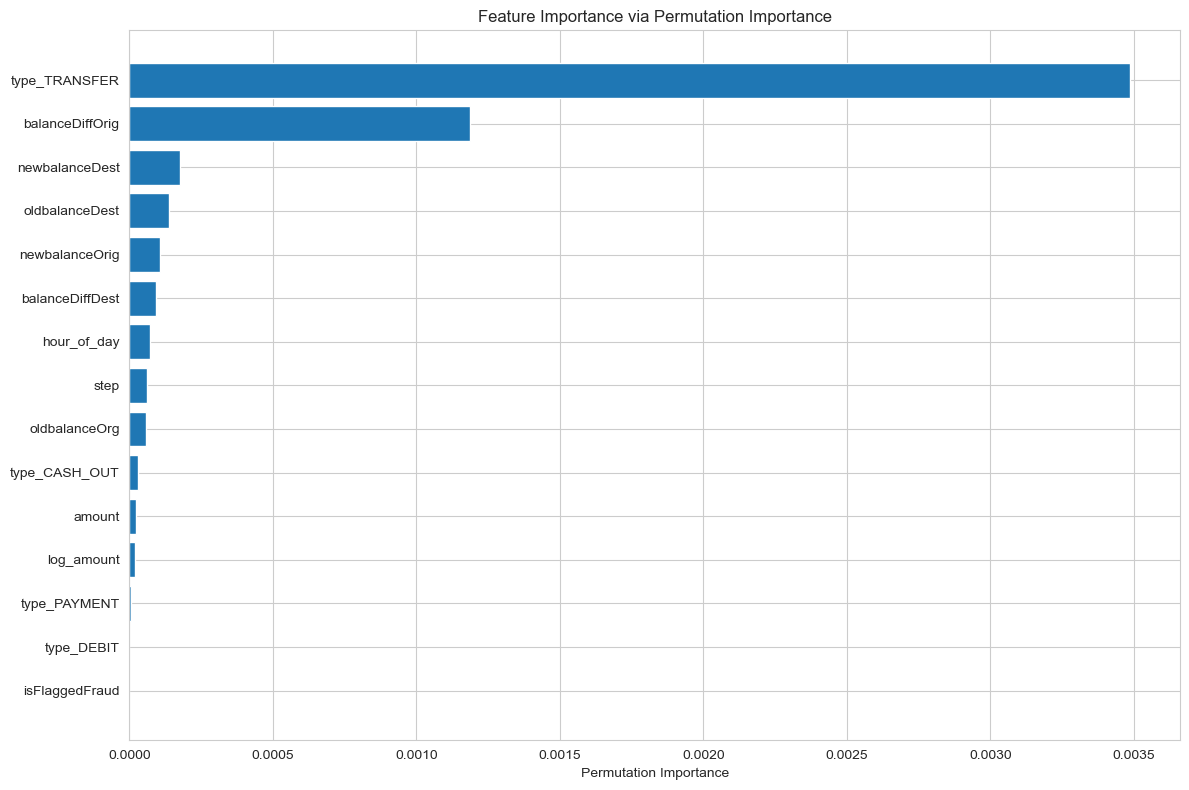

In [104]:
# 정렬 후 시각화
sorted_idx = perm_importance.importances_mean.argsort()

plt.figure(figsize=(12, 8))

plt.barh(x.columns[sorted_idx], perm_importance.importances_mean[sorted_idx])

plt.title('Feature Importance via Permutation Importance')
plt.xlabel('Permutation Importance')

plt.tight_layout()
plt.show()

In [106]:
# amount: 데이터 탐색 과정에서 사기 거래에서 나타나는 특징이 amount에서 계속 나타남
# balanceDiffOrig: 통계검정, ML 기법 두가지에서 모두 주요 feature로 선정됨
from sklearn.preprocessing import StandardScaler

key_features = ['amount', 'balanceDiffOrig'] # Key Feature
plot_data = data_encoded[key_features + ['isFraud']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(plot_data[key_features])

plot_data_scaled = pd.DataFrame(scaled_features, columns=key_features)
plot_data_scaled['isFraud'] = plot_data['isFraud'].values

colors = plot_data_scaled['isFraud'].map({0: 'blue', 1:'red'})

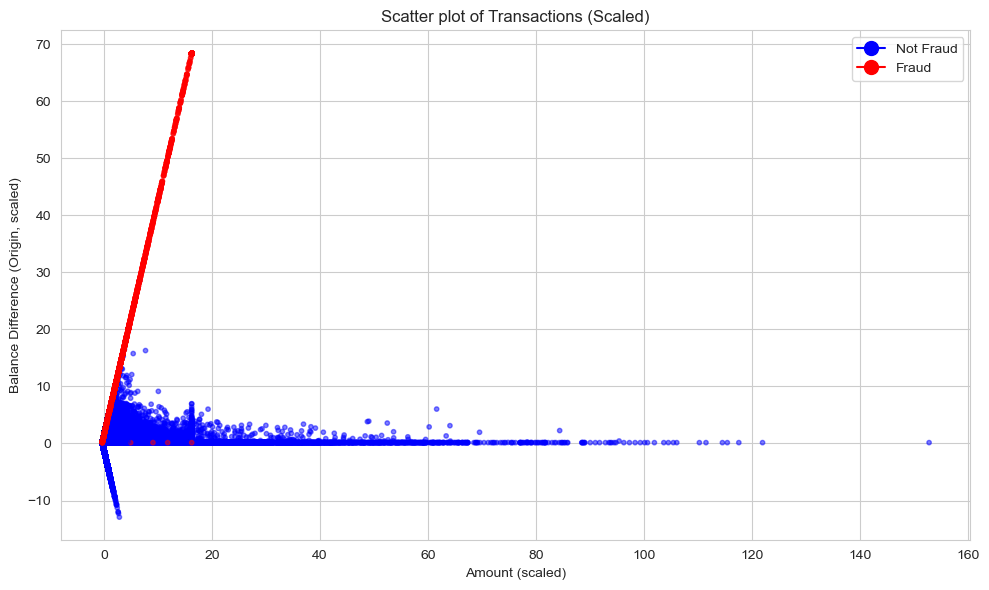

In [107]:
# 거래금액(amount), balanceDiffOrig(발신자 거래 전후 내역 차이)에 따른 데이터 포인트
# 정상거래의 경우 amount에 관계없이 내역 차이가 0에 분포되어 있는 반면
# 사기거래의 경우 거래금액이 커질수록 계좌 내역 차이가 급격히 커짐
# 따라서 사기거래의 경우 정상거래보다 계좌 내역 차이가 거래금액에 따라 큰 차이를 보인다.
plt.figure(figsize=(10, 6))

plt.scatter(plot_data_scaled['amount'],
            plot_data_scaled['balanceDiffOrig'],
            c=colors,
            alpha=0.5,
            s=10,
            label='isFraud')

plt.title('Scatter plot of Transactions (Scaled)')
plt.xlabel('Amount (scaled)')
plt.ylabel('Balance Difference (Origin, scaled)')
plt.legend(handles=[plt.Line2D([0], [0], color='blue', marker='o', markersize=10, label='Not Fraud'),
                    plt.Line2D([0], [0], color='red', marker='o', markersize=10, label='Fraud')],
            loc='upper right')

plt.grid(True)
plt.tight_layout()
plt.show()